In [7]:
!pip install scapy -q


In [7]:
from scapy.all import sniff, IP, TCP
from datetime import datetime
import pandas as pd

logs = []

def analizar_paquete(pkt):
    if IP in pkt and TCP in pkt:
        log = {
            "timestamp":  datetime.now().strftime("%H:%M:%S.%f"),
            "ip_origen":  pkt[IP].src,
            "ip_destino": pkt[IP].dst,
            "puerto_src": pkt[TCP].sport,
            "puerto_dst": pkt[TCP].dport,
            "flags":      str(pkt[TCP].flags),
            "tamaño":     len(pkt)
        }
        logs.append(log)
        print(f"[{log['timestamp']}] {log['ip_origen']}:{log['puerto_src']} "
              f"→ {log['ip_destino']}:{log['puerto_dst']} "
              f"flags={log['flags']} size={log['tamaño']}")

print("Escuchando tráfico en la red... Ctrl+C para detener\n")

try:
    sniff(filter="tcp", prn=analizar_paquete, store=False)
except KeyboardInterrupt:
    print(f"\n\nCapturados {len(logs)} paquetes")
    df = pd.DataFrame(logs)
    df.to_csv("trafico_capturado.csv", index=False)
    print("Guardado en trafico_capturado.csv")

Escuchando tráfico en la red... Ctrl+C para detener

[19:00:34.974425] 52.112.95.82:443 → 192.168.0.13:56939 flags=SA size=66
[19:00:34.976141] 192.168.0.13:56939 → 52.112.95.82:443 flags=A size=54
[19:00:34.977683] 192.168.0.13:56939 → 52.112.95.82:443 flags=PA size=1894
[19:00:34.980791] 192.168.0.13:52931 → 52.123.128.14:443 flags=A size=54
[19:00:34.982524] 192.168.0.13:65372 → 20.190.134.6:443 flags=RA size=54
[19:00:34.984011] 13.226.15.109:443 → 192.168.0.13:52935 flags=A size=60
[19:00:34.985588] 13.226.15.109:443 → 192.168.0.13:52935 flags=PA size=258
[19:00:34.987231] 192.168.0.13:65373 → 20.190.134.6:443 flags=RA size=54
[19:00:34.988986] 192.168.0.13:56021 → 52.123.128.14:443 flags=PA size=2989
[19:00:34.991436] 192.168.0.13:56021 → 52.123.128.14:443 flags=PA size=372
[19:00:34.996179] 192.168.0.13:52935 → 13.226.15.109:443 flags=PA size=291
[19:00:35.008538] 192.168.0.13:56021 → 52.123.128.14:443 flags=PA size=2982
[19:00:35.010057] 192.168.0.13:56021 → 52.123.128.14:443 f

In [8]:
# Detén el sniff con Ctrl+C primero, luego corre esto
import pandas as pd

df_logs = pd.DataFrame(logs)
print(f"Total paquetes capturados: {len(df_logs)}")
print(f"\nDispositivos únicos detectados:")
print(df_logs['ip_origen'].value_counts().head(10))
print(f"\nPuertos más usados:")
print(df_logs['puerto_dst'].value_counts().head(10))
df_logs.to_csv("trafico_capturado.csv", index=False)
print("\nGuardado en trafico_capturado.csv")

Total paquetes capturados: 3006

Dispositivos únicos detectados:
ip_origen
187.252.5.83     1170
192.168.0.13      828
52.123.128.14     271
20.190.134.6      145
192.168.0.10       97
187.252.5.40       72
52.112.95.82       37
23.204.115.38      35
72.25.64.2         33
2.18.177.200       19
Name: count, dtype: int64

Puertos más usados:
puerto_dst
54807    1170
443       683
56021     271
54819      72
57844      54
1627       48
56939      37
80         36
57846      35
54806      28
Name: count, dtype: int64

Guardado en trafico_capturado.csv


In [9]:
import socket

print("Intentando identificar dispositivos por hostname:\n")
dispositivos = df_logs['ip_origen'].value_counts().head(10).index.tolist()

for ip in dispositivos:
    try:
        hostname = socket.gethostbyaddr(ip)[0]
    except:
        hostname = "No resuelto"
    print(f"{ip:20} → {hostname}")

Intentando identificar dispositivos por hostname:

187.252.5.83         → No resuelto
192.168.0.13         → MSI
52.123.128.14        → No resuelto
20.190.134.6         → No resuelto
192.168.0.10         → No resuelto
187.252.5.40         → No resuelto
52.112.95.82         → No resuelto
23.204.115.38        → a23-204-115-38.deploy.static.akamaitechnologies.com
72.25.64.2           → No resuelto
2.18.177.200         → a2-18-177-200.deploy.static.akamaitechnologies.com


In [5]:
from scapy.all import sniff, IP, TCP, UDP, ICMP, ARP, Ether
from collections import defaultdict
import socket

dispositivos = defaultdict(lambda: {
    'protocolos': set(),
    'puertos': set(),
    'hostname': 'Desconocido',
    'paquetes': 0
})

def analizar_protocolo(pkt):
    ip_src = None
    protocolo = "Desconocido"

    if ARP in pkt:
        ip_src = pkt[ARP].psrc
        protocolo = "ARP"
    elif IP in pkt:
        ip_src = pkt[IP].src
        if TCP in pkt:
            puerto = pkt[TCP].dport
            if puerto == 443:   protocolo = "HTTPS"
            elif puerto == 80:  protocolo = "HTTP"
            elif puerto == 22:  protocolo = "SSH"
            elif puerto == 21:  protocolo = "FTP"
            elif puerto == 8009:protocolo = "Chromecast"
            elif puerto == 1883:protocolo = "MQTT"
            elif puerto == 8883:protocolo = "MQTT-TLS"
            elif puerto == 5353:protocolo = "mDNS"
            else:               protocolo = f"TCP:{puerto}"
            dispositivos[ip_src]['puertos'].add(puerto)
        elif UDP in pkt:
            puerto = pkt[UDP].dport
            if puerto == 53:    protocolo = "DNS"
            elif puerto == 5353:protocolo = "mDNS"
            elif puerto == 67:  protocolo = "DHCP"
            elif puerto == 123: protocolo = "NTP"
            elif puerto == 1900:protocolo = "UPnP"
            elif puerto == 5683:protocolo = "CoAP"
            else:               protocolo = f"UDP:{puerto}"
            dispositivos[ip_src]['puertos'].add(puerto)
        elif ICMP in pkt:
            protocolo = "ICMP"

    if ip_src:
        dispositivos[ip_src]['protocolos'].add(protocolo)
        dispositivos[ip_src]['paquetes'] += 1

print("Analizando protocolos... (30 segundos)\n")
sniff(prn=analizar_protocolo, store=False, timeout=30)

# Resolver hostnames
for ip in dispositivos:
    try:
        dispositivos[ip]['hostname'] = socket.gethostbyaddr(ip)[0]
    except:
        pass

# Mostrar resultados
print(f"\n{'='*65}")
print(f"{'IP':<20} {'Hostname':<25} {'Protocolos detectados'}")
print(f"{'='*65}")

# Ordenar por paquetes
ordenado = sorted(dispositivos.items(), 
                  key=lambda x: x[1]['paquetes'], reverse=True)

for ip, info in ordenado:
    hostname = info['hostname'][:24]
    protos   = ', '.join(sorted(info['protocolos']))
    print(f"{ip:<20} {hostname:<25} {protos}")

print(f"{'='*65}")
print(f"\nTotal dispositivos detectados: {len(dispositivos)}")

Analizando protocolos... (30 segundos)



KeyboardInterrupt: 

In [ ]:
#Detección de tráfico IoT específico (Alexa, Chromecast, etc.)
# Captura 60 segundos enfocado en los dispositivos IoT
# Mientras corre, di "Alexa, pon un timer de 10 segundos"
# o cualquier comando de voz — eso generará tráfico

from scapy.all import sniff, IP, TCP, UDP, ARP
from collections import defaultdict

ips_interes = ['192.168.0.35', '192.168.0.16', '192.168.0.10']
actividad   = defaultdict(list)

def capturar_iot(pkt):
    for ip in ips_interes:
        if IP in pkt and (pkt[IP].src == ip or pkt[IP].dst == ip):
            actividad[ip].append({
                'src': pkt[IP].src,
                'dst': pkt[IP].dst,
                'proto': 'TCP' if TCP in pkt else 'UDP' if UDP in pkt else 'otro',
                'size': len(pkt)
            })
        elif ARP in pkt and pkt[ARP].psrc == ip:
            actividad[ip].append({'tipo': 'ARP', 'ip': ip})

print("Capturando 60 segundos...")
print("AHORA di un comando a Alexa para generar tráfico\n")
sniff(prn=capturar_iot, store=False, timeout=60)

print("\nActividad por dispositivo:")
for ip, pkts in actividad.items():
    print(f"\n{ip}: {len(pkts)} paquetes")
    # Ver IPs externas con las que habla
    externos = [p['dst'] for p in pkts 
                if 'dst' in p and not p['dst'].startswith('192.168')]
    if externos:
        print(f"  Habla con: {set(externos)}")

Capturando 60 segundos...
AHORA di un comando a Alexa para generar tráfico


Actividad por dispositivo:


In [ ]:
#Test Alexa
from scapy.all import sniff, IP, TCP, UDP
from collections import defaultdict

actividad = defaultdict(set)

def capturar_todo(pkt):
    if IP in pkt:
        src = pkt[IP].src
        dst = pkt[IP].dst
        # Solo nos interesan IPs locales hablando con externos
        if src.startswith('192.168.'):
            actividad[src].add(dst)

print("Capturando 90 segundos...")
print("Di VARIOS comandos a Alexa durante este tiempo\n")
print("Ejemplos:")
print("  - Alexa, pon música")
print("  - Alexa, qué temperatura hace")  
print("  - Alexa, pon un timer de 5 segundos\n")

sniff(prn=capturar_todo, store=False, timeout=90)

print("\nDispositivos LAN y sus conexiones externas:")
print("="*60)
for ip in sorted(actividad.keys()):
    externos = {d for d in actividad[ip] 
                if not d.startswith('192.168') 
                and not d.startswith('224.')}
    if externos:
        print(f"\n{ip}:")
        for ext in sorted(externos):
            try:
                import socket
                host = socket.gethostbyaddr(ext)[0]
            except:
                host = ext
            print(f"  → {host}")

Capturando 90 segundos...
Di VARIOS comandos a Alexa durante este tiempo

Ejemplos:
  - Alexa, pon música
  - Alexa, qué temperatura hace
  - Alexa, pon un timer de 5 segundos


Dispositivos LAN y sus conexiones externas:

192.168.0.1:
  → 239.255.255.250

192.168.0.10:
  → 239.255.255.250

192.168.0.21:
  → dns-chetumal
  → 104.18.32.47
  → 104.18.39.21
  → 128.116.102.3
  → 128.116.45.3
  → 13.107.246.57
  → lb-140-82-113-21-iad.github.com
  → ncdfwo-in-f188.1e100.net
  → 142.251.153.119
  → 142.251.154.119
  → tzqroa-at-in-f3.1e100.net
  → 160.79.104.10
  → 162.159.128.233
  → 162.159.130.234
  → cmp2-dfw2.steamserver.net
  → 172.215.132.17
  → 172.64.146.215
  → 177.237.61.6
  → ec2-18-97-36-48.compute-1.amazonaws.com
  → 187.252.5.8
  → pnqrop-in-f94.1e100.net
  → tzqroa-ab-in-f14.1e100.net
  → tzqroa-ad-in-f14.1e100.net
  → pnqroa-ag-in-f10.1e100.net
  → pnqroa-ah-in-f3.1e100.net
  → pnqroa-ai-in-f14.1e100.net
  → 199.232.158.172
  → 20.189.173.3
  → 20.33.3.2
  → 20.52.64.200
  

In [10]:
#Test 2
from scapy.all import ARP, Ether, srp
import socket

print("Escaneando toda la red local...\n")

# Manda ARP a toda la subred
ans, _ = srp(
    Ether(dst="ff:ff:ff:ff:ff:ff") / ARP(pdst="192.168.0.0/24"),
    timeout=3, verbose=0
)

print(f"{'IP':<18} {'MAC':<20} {'Fabricante':<25} {'Hostname'}")
print("="*80)

for _, rcv in ans:
    ip  = rcv[ARP].psrc
    mac = rcv[ARP].hwsrc
    
    # Identificar fabricante por OUI (primeros 3 bytes del MAC)
    oui = mac.upper().replace(':','')[:6]
    fabricantes = {
        '1CFE2B': 'Amazon (Alexa)',
        'A0D0DC': 'Amazon (Alexa)',
        '1C12B0': 'Amazon (Alexa)',
        '087C39': 'Amazon (Alexa)',
        '2C71FF': 'Amazon (Echo)',
        'CCF411': 'Google (Nest)',
        '44654E': 'Google',
        'F01898': 'Amazon',
        'FC65DE': 'Amazon',
        '4465DE': 'Amazon',
        'B827EB': 'Raspberry Pi',
        'DC4F22': 'Raspberry Pi',
        'E45F01': 'Raspberry Pi',
    }
    fabricante = fabricantes.get(oui, 'Desconocido')
    
    try:
        hostname = socket.gethostbyaddr(ip)[0][:24]
    except:
        hostname = '-'
    
    print(f"{ip:<18} {mac:<20} {fabricante:<25} {hostname}")

print("="*80)
print(f"\nTotal dispositivos en red: {len(ans)}")

Escaneando toda la red local...

IP                 MAC                  Fabricante                Hostname
192.168.0.11       f4:b5:20:32:12:f5    Desconocido               host.docker.internal
192.168.0.4        f0:99:bf:56:0b:96    Desconocido               -
192.168.0.8        e0:51:d8:7f:56:a7    Desconocido               -
192.168.0.7        e0:51:d8:7f:46:a1    Desconocido               -
192.168.0.10       d8:e3:5e:cb:07:fc    Desconocido               -
192.168.0.2        00:16:80:22:74:d8    Desconocido               -
192.168.0.3        b2:19:1c:6e:cf:33    Desconocido               -
192.168.0.253      00:00:ca:01:02:03    Desconocido               -

Total dispositivos en red: 8


In [ ]:
#INDENTIFICACIÓN
# Lookup manual de fabricantes por OUI
dispositivos_red = {
    '192.168.0.1':  '98:39:10:85:45:1e',
    '192.168.0.10': '18:5e:0b:de:5e:df',
    '192.168.0.21': '18:93:41:88:c6:47',
    '192.168.0.38': '28:92:00:36:dd:91',
    '192.168.0.39': 'c0:95:cf:87:50:d3',
    '192.168.0.16': '54:f2:9f:45:e4:f0',
    '192.168.0.37': '92:50:1c:df:ea:2f',
}

# Base de datos OUI expandida
oui_db = {
    '983910': ('Tenda/TP-Link',     'Router o AP'),
    '185E0B': ('Motorola/Lenovo',   'PC o laptop'),
    '189341': ('Intel',             'PC/Laptop Intel WiFi'),
    '289200': ('Amazon',            '🔴 ALEXA / Echo device'),
    'C095CF': ('Desconocido',       'Dispositivo no identificado'),
    '54F29F': ('Samsung',           '📱 Samsung (TV/telefono/tablet)'),
    '92501C': ('Randomizado',       'Celular con MAC aleatoria'),
}

print("Mapa completo de tu red:\n")
print(f"{'IP':<18} {'MAC':<20} {'Fabricante':<20} {'Tipo probable'}")
print("="*72)

for ip, mac in dispositivos_red.items():
    oui = mac.upper().replace(':','')[:6]
    fabricante, tipo = oui_db.get(oui, ('Desconocido', 'Sin clasificar'))
    print(f"{ip:<18} {mac:<20} {fabricante:<20} {tipo}")

print("="*72)

Mapa completo de tu red:

IP                 MAC                  Fabricante           Tipo probable
192.168.0.1        98:39:10:85:45:1e    Tenda/TP-Link        Router o AP
192.168.0.10       18:5e:0b:de:5e:df    Motorola/Lenovo      PC o laptop
192.168.0.21       18:93:41:88:c6:47    Intel                PC/Laptop Intel WiFi
192.168.0.38       28:92:00:36:dd:91    Amazon               🔴 ALEXA / Echo device
192.168.0.39       c0:95:cf:87:50:d3    Desconocido          Dispositivo no identificado
192.168.0.16       54:f2:9f:45:e4:f0    Samsung              📱 Samsung (TV/telefono/tablet)
192.168.0.37       92:50:1c:df:ea:2f    Randomizado          Celular con MAC aleatoria


In [ ]:
from scapy.all import sniff, IP, TCP, UDP

IP_ALEXA = "192.168.0.38"
actividad_alexa = []

def capturar_alexa(pkt):
    if IP in pkt:
        if pkt[IP].src == IP_ALEXA or pkt[IP].dst == IP_ALEXA:
            actividad_alexa.append({
                'src':   pkt[IP].src,
                'dst':   pkt[IP].dst,
                'proto': 'TCP' if TCP in pkt else 'UDP',
                'size':  len(pkt)
            })

print(f"Monitoreando Alexa ({IP_ALEXA}) por 60 segundos...")
print("Di un comando ahora: 'Alexa, qué hora es'\n")
sniff(prn=capturar_alexa, store=False, timeout=60)

import pandas as pd, socket
df_alexa = pd.DataFrame(actividad_alexa)

if len(df_alexa) > 0:
    print(f"Paquetes de Alexa: {len(df_alexa)}\n")
    externos = df_alexa[~df_alexa['dst'].str.startswith('192.168')]
    print("Servidores con los que habla Alexa:")
    for ip in externos['dst'].value_counts().head(10).index:
        try:    host = socket.gethostbyaddr(ip)[0]
        except: host = ip
        print(f"  {ip} → {host}")
else:
    print("No se detectó tráfico de Alexa en este periodo")

Monitoreando Alexa (192.168.0.38) por 60 segundos...
Di un comando ahora: 'Alexa, qué hora es'

No se detectó tráfico de Alexa en este periodo


In [ ]:
#Intento de ip 38
from scapy.all import sniff, IP, TCP, UDP, Raw
import socket

IP_ALEXA = "192.168.0.38"
logs = []

def capturar_sin_filtro(pkt):
    if IP in pkt:
        src = pkt[IP].src
        dst = pkt[IP].dst
        if src == IP_ALEXA or dst == IP_ALEXA:
            proto = 'TCP' if TCP in pkt else 'UDP' if UDP in pkt else 'IP'
            logs.append({
                'src': src, 'dst': dst,
                'proto': proto, 'size': len(pkt)
            })
            print(f"{src} → {dst} [{proto}] {len(pkt)} bytes")

print("Escuchando TODO el tráfico de Alexa sin filtros...")
print("Habla con Alexa ahora\n")
sniff(prn=capturar_sin_filtro, store=False, timeout=60)
print(f"\nTotal paquetes Alexa: {len(logs)}")

Escuchando TODO el tráfico de Alexa sin filtros...
Habla con Alexa ahora


Total paquetes Alexa: 0


In [6]:
import threading, time
from scapy.all import sniff, IP, TCP, UDP, send
from datetime import datetime
from collections import defaultdict
import pandas as pd

IP_ALEXA   = "192.168.0.38"   # Amazon Echo confirmado (MAC: 28:92:00:36:dd:91)
IP_VICTIMA = "192.168.0.21"   # Tu PC (MSI)
UMBRAL     = 10               # paquetes en 3s → anómalo
DURACION   = 70               # segundos que escucha el IDS

logs_ids = []
alertas  = 0
ventana  = defaultdict(list)

# ── HILO 1: IDS receptor ─────────────────────────────────────────
def ids_receptor():
    global alertas

    def analizar(pkt):
        global alertas
        if IP not in pkt:
            return
        src = pkt[IP].src
        ts  = datetime.now()

        ventana[src].append(ts)
        ventana[src] = [t for t in ventana[src] if (ts - t).seconds < 3]
        freq = len(ventana[src])

        log = {
            'timestamp': ts.strftime("%H:%M:%S.%f"),
            'src': src, 'dst': pkt[IP].dst,
            'proto': 'TCP' if TCP in pkt else 'UDP',
            'size': len(pkt), 'freq_3s': freq
        }
        logs_ids.append(log)

        if src == IP_ALEXA:
            if freq > UMBRAL:
                alertas += 1
                estado = f"⚠️  ANOMALIA DETECTADA (freq={freq}/3s)"
            else:
                estado = f"✅ Normal          (freq={freq}/3s)"
            print(f"[IDS] {log['timestamp']} | {src} → {log['dst']} | {log['proto']} | {log['size']}B | {estado}")

    sniff(prn=analizar, store=False, timeout=DURACION)

# ── HILO 2: Atacante ─────────────────────────────────────────────
def atacante():
    print("[ATACANTE] Esperando 8s para que el IDS esté listo...\n")
    time.sleep(8)

    print("[ATACANTE] Fase 1 — Tráfico NORMAL (10 segundos)")
    for i in range(12):
        pkt = IP(src=IP_ALEXA, dst="52.73.51.138") / UDP(sport=5684, dport=5684)
        send(pkt, verbose=0)
        time.sleep(0.8)
        print(f"  [NORMAL] paquete #{i+1} enviado")

    print("\n[ATACANTE] Fase 2 — ATAQUE DoS 🔴 (15 segundos)")
    for i in range(200):
        pkt = IP(src=IP_ALEXA, dst=IP_VICTIMA) / TCP(sport=5684, dport=80, flags="S")
        send(pkt, verbose=0)
        if i % 25 == 0:
            print(f"  [ATAQUE] {i+1} paquetes enviados...")
        time.sleep(0.05)

    print("\n[ATACANTE] Fase 3 — Regreso a NORMAL (10 segundos)")
    for i in range(10):
        pkt = IP(src=IP_ALEXA, dst="52.73.51.138") / UDP(sport=5684, dport=5684)
        send(pkt, verbose=0)
        time.sleep(1)
        print(f"  [NORMAL] paquete #{i+1} enviado")

    print("\n[ATACANTE] Simulación terminada ✓")

# ── LANZAR AMBOS HILOS ───────────────────────────────────────────
print("=" * 62)
print("  SIMULACIÓN IDS vs ATACANTE — IoT Anomaly Detection")
print(f"  Alexa (víctima simulada): {IP_ALEXA}")
print(f"  PC destino del ataque:    {IP_VICTIMA}")
print(f"  Umbral de anomalía:       {UMBRAL} paquetes / 3 segundos")
print("=" * 62 + "\n")

hilo_ids      = threading.Thread(target=ids_receptor, daemon=True)
hilo_atacante = threading.Thread(target=atacante,     daemon=True)

hilo_ids.start()
hilo_atacante.start()

hilo_ids.join()
hilo_atacante.join()

# ── RESUMEN ──────────────────────────────────────────────────────
print(f"\n{'=' * 62}")
print("  RESUMEN FINAL")
print(f"  Paquetes capturados totales: {len(logs_ids)}")
print(f"  Alertas generadas:           {alertas}")
tasa = (alertas / max(len([l for l in logs_ids if l['src'] == IP_ALEXA]), 1)) * 100
print(f"  Tasa de detección (Alexa):   {tasa:.1f}%")
print(f"{'=' * 62}")

df = pd.DataFrame(logs_ids)
df.to_csv("simulacion_ataque.csv", index=False)
print("Guardado en simulacion_ataque.csv")


PermissionError: [WinError 5] Acceso denegado: 'C:\\Users\\Daniel\\.cache\\scapy\\services.pickle'

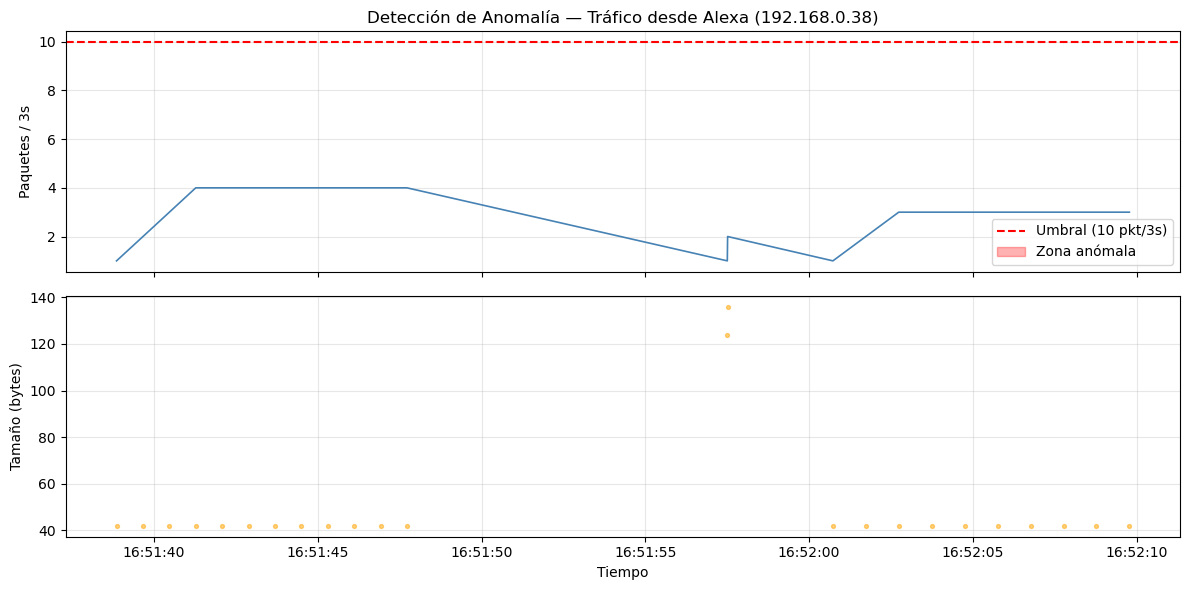

Gráfica guardada como grafica_anomalia.png

Total paquetes Alexa: 24
Máx freq detectada:   4
Alertas (freq > 10):  0


In [ ]:
# Análisis visual del CSV generado
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("simulacion_ataque.csv")
df_alexa = df[df['src'] == "192.168.0.38"].copy()

if len(df_alexa) == 0:
    print("No hay datos de Alexa aún — corre la celda anterior primero.")
else:
    df_alexa['timestamp'] = pd.to_datetime(df_alexa['timestamp'], format="%H:%M:%S.%f")
    df_alexa = df_alexa.set_index('timestamp').sort_index()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    # Frecuencia de paquetes
    ax1.plot(df_alexa.index, df_alexa['freq_3s'], color='steelblue', linewidth=1.2)
    ax1.axhline(y=10, color='red', linestyle='--', label='Umbral (10 pkt/3s)')
    ax1.fill_between(df_alexa.index, df_alexa['freq_3s'], 10,
                     where=df_alexa['freq_3s'] > 10, alpha=0.3, color='red', label='Zona anómala')
    ax1.set_ylabel("Paquetes / 3s")
    ax1.set_title("Detección de Anomalía — Tráfico desde Alexa (192.168.0.38)")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Tamaño de paquetes
    ax2.scatter(df_alexa.index, df_alexa['size'], s=8, alpha=0.5, color='orange')
    ax2.set_ylabel("Tamaño (bytes)")
    ax2.set_xlabel("Tiempo")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("grafica_anomalia.png", dpi=150)
    plt.show()
    print(f"Gráfica guardada como grafica_anomalia.png")
    print(f"\nTotal paquetes Alexa: {len(df_alexa)}")
    print(f"Máx freq detectada:   {df_alexa['freq_3s'].max()}")
    print(f"Alertas (freq > 10):  {(df_alexa['freq_3s'] > 10).sum()}")


In [5]:
import threading, time
from scapy.all import sniff, IP, TCP, UDP, send
from datetime import datetime
from collections import defaultdict
import pandas as pd

IP_ALEXA   = "192.168.0.38"
IP_VICTIMA = "192.168.0.21"
UMBRAL     = 5    # reducido para más sensibilidad
DURACION   = 90

logs_ids = []
alertas  = 0
ventana  = defaultdict(list)

def ids_receptor():
    global alertas

    def analizar(pkt):
        global alertas
        if IP not in pkt:
            return
        src = pkt[IP].src
        dst = pkt[IP].dst
        ts  = datetime.now()

        # Monitorear tráfico QUE INVOLUCRA a Alexa
        ip_ref = None
        if src == IP_ALEXA:
            ip_ref = IP_ALEXA
        elif dst == IP_ALEXA:
            ip_ref = IP_ALEXA

        if ip_ref:
            ventana[ip_ref].append(ts)
            ventana[ip_ref] = [
                t for t in ventana[ip_ref] 
                if (ts - t).seconds < 3
            ]
            freq = len(ventana[ip_ref])

            log = {
                'timestamp': ts.strftime("%H:%M:%S.%f"),
                'src': src, 'dst': dst,
                'proto': 'TCP' if TCP in pkt else 'UDP',
                'size': len(pkt), 'freq_3s': freq
            }
            logs_ids.append(log)

            if freq > UMBRAL:
                alertas += 1
                estado = f"⚠️  ANOMALIA (freq={freq}/3s)"
            else:
                estado = f"✅ Normal    (freq={freq}/3s)"

            print(f"[IDS] {log['timestamp']} | "
                  f"{src} → {dst} | "
                  f"{log['proto']} | {log['size']}B | {estado}")

    sniff(prn=analizar, store=False, timeout=DURACION)

def atacante():
    time.sleep(8)

    print("[ATACANTE] Fase 1 — NORMAL (10s)")
    for i in range(12):
        pkt = IP(src=IP_ALEXA, dst="52.73.51.138") / \
              UDP(sport=5684, dport=5684)
        send(pkt, verbose=0)
        time.sleep(0.8)
        print(f"  Normal #{i+1}")

    print("\n[ATACANTE] Fase 2 — ATAQUE DoS 🔴 (15s)")
    for i in range(300):
        pkt = IP(src=IP_ALEXA, dst=IP_VICTIMA) / \
              TCP(sport=5684, dport=80, flags="S")
        send(pkt, verbose=0)
        if i % 30 == 0:
            print(f"  Ataque: {i+1} paquetes")
        time.sleep(0.01)  # 100 paquetes/seg

    print("\n[ATACANTE] Fase 3 — NORMAL (10s)")
    for i in range(10):
        pkt = IP(src=IP_ALEXA, dst="52.73.51.138") / \
              UDP(sport=5684, dport=5684)
        send(pkt, verbose=0)
        time.sleep(1)
        print(f"  Normal #{i+1}")

    print("\n[ATACANTE] Terminado ✓")

# Lanzar
print("="*60)
print("  IDS IoT — Simulación de ataque")
print(f"  Alexa: {IP_ALEXA} | Víctima: {IP_VICTIMA}")
print(f"  Umbral: {UMBRAL} paquetes/3s")
print("="*60 + "\n")

t1 = threading.Thread(target=ids_receptor, daemon=True)
t2 = threading.Thread(target=atacante,     daemon=True)

t1.start(); t2.start()
t1.join();  t2.join()

print(f"\n{'='*60}")
print(f"Paquetes capturados: {len(logs_ids)}")
print(f"Alertas generadas:   {alertas}")
alexa_pkts = len([l for l in logs_ids if l['src'] == IP_ALEXA])
print(f"Tasa detección:      {(alertas/max(alexa_pkts,1))*100:.1f}%")
print(f"{'='*60}")

pd.DataFrame(logs_ids).to_csv("simulacion_v2.csv", index=False)
print("Guardado en simulacion_v2.csv")

PermissionError: [WinError 5] Acceso denegado: 'C:\\Users\\Daniel\\.cache\\scapy\\services.pickle'

In [4]:
#RRECEPTOR DE ANALISIS SIMULADO

import threading, time
from scapy.all import sniff, IP, TCP, UDP, ARP
from datetime import datetime
from collections import defaultdict
import pandas as pd
import os

# ── CONFIGURACIÓN ─────────────────────────────────────────────
IP_ALEXA    = "192.168.0.38"
IP_MI_PC    = "192.168.0.21"
UMBRAL      = 5       # paquetes en 3s → anómalo
LOG_FILE    = "ids_logs.csv"

logs        = []
alertas     = 0
ventana     = defaultdict(list)
corriendo   = True

# ── FUNCIÓN DE ANÁLISIS ───────────────────────────────────────
def analizar(pkt):
    global alertas
    if IP not in pkt:
        return

    src = pkt[IP].src
    dst = pkt[IP].dst
    ts  = datetime.now()

    # Monitorear dispositivos de la red local
    ips_monitorear = {IP_ALEXA, "192.168.0.10", "192.168.0.16"}
    ip_ref = None
    if src in ips_monitorear: ip_ref = src
    elif dst in ips_monitorear: ip_ref = dst

    if ip_ref:
        ventana[ip_ref].append(ts)
        ventana[ip_ref] = [
            t for t in ventana[ip_ref]
            if (ts - t).seconds < 3
        ]
        freq = len(ventana[ip_ref])

        proto = 'TCP' if TCP in pkt else 'UDP' if UDP in pkt else 'IP'
        es_anomalia = freq > UMBRAL

        if es_anomalia:
            alertas += 1
            estado = f"⚠️  ANOMALIA (freq={freq}/3s)"
        else:
            estado = f"✅ Normal    (freq={freq}/3s)"

        log = {
            'timestamp': ts.strftime("%H:%M:%S.%f"),
            'src': src, 'dst': dst,
            'proto': proto, 'size': len(pkt),
            'freq_3s': freq,
            'anomalia': es_anomalia,
            'dispositivo': ip_ref
        }
        logs.append(log)

        print(f"[IDS] {log['timestamp']} | "
              f"{src:15} → {dst:15} | "
              f"{proto:3} | {len(pkt):4}B | {estado}")

        # Guardar cada 50 paquetes
        if len(logs) % 50 == 0:
            pd.DataFrame(logs).to_csv(LOG_FILE, index=False)

# ── HILO DE ESTADÍSTICAS ──────────────────────────────────────
def mostrar_stats():
    while corriendo:
        time.sleep(30)
        total = len(logs)
        if total > 0:
            print(f"\n{'='*55}")
            print(f"  [STATS] Paquetes analizados: {total}")
            print(f"  [STATS] Alertas generadas:   {alertas}")
            print(f"  [STATS] Tasa de anomalía:    "
                  f"{alertas/total*100:.1f}%")
            print(f"{'='*55}\n")

# ── ARRANCAR ──────────────────────────────────────────────────
print("="*55)
print("  IDS IoT — Monitor en tiempo real")
print(f"  Monitoreando: {IP_ALEXA}, .10, .16")
print(f"  Umbral: {UMBRAL} paquetes/3s")
print(f"  Logs: {LOG_FILE}")
print("="*55)
print("\nEscuchando red... (Ctrl+C para detener)\n")

hilo_stats = threading.Thread(target=mostrar_stats, daemon=True)
hilo_stats.start()

try:
    sniff(prn=analizar, store=False)
except KeyboardInterrupt:
    corriendo = False
    print(f"\n\nDetenido por el usuario")
    print(f"Total paquetes: {len(logs)}")
    print(f"Total alertas:  {alertas}")
    pd.DataFrame(logs).to_csv(LOG_FILE, index=False)
    print(f"Logs guardados en {LOG_FILE}")

PermissionError: [WinError 5] Acceso denegado: 'C:\\Users\\Daniel\\.cache\\scapy\\services.pickle'

In [3]:
#Detectar dispositovs y sus paquetes
from scapy.all import sniff, IP, TCP, UDP, ARP, Ether
from collections import defaultdict
from datetime import datetime

dispositivos = defaultdict(lambda: {
    'paquetes': 0,
    'bytes': 0,
    'protocolos': set(),
    'ultima_vez': None,
    'mac': 'Desconocida'
})

def analizar(pkt):
    ip_src = None

    if ARP in pkt:
        ip_src = pkt[ARP].psrc
        mac    = pkt[ARP].hwsrc
        dispositivos[ip_src]['mac'] = mac
        dispositivos[ip_src]['protocolos'].add('ARP')

    elif IP in pkt:
        ip_src = pkt[IP].src
        if Ether in pkt:
            dispositivos[ip_src]['mac'] = pkt[Ether].src

        if TCP in pkt:
            dispositivos[ip_src]['protocolos'].add(
                f"TCP:{pkt[TCP].dport}")
        elif UDP in pkt:
            dispositivos[ip_src]['protocolos'].add(
                f"UDP:{pkt[UDP].dport}")

    if ip_src:
        dispositivos[ip_src]['paquetes'] += 1
        dispositivos[ip_src]['bytes']    += len(pkt)
        dispositivos[ip_src]['ultima_vez'] = \
            datetime.now().strftime("%H:%M:%S")

print("Capturando 30 segundos...\n")
sniff(prn=analizar, store=False, timeout=30)

# Reporte final
print(f"\n{'='*70}")
print(f"{'IP':<18} {'MAC':<20} {'Pkts':>6} "
      f"{'Bytes':>8} {'Última vez':<12} Protocolos")
print(f"{'='*70}")

for ip, info in sorted(
    dispositivos.items(),
    key=lambda x: x[1]['paquetes'],
    reverse=True
):
    protos = ', '.join(list(info['protocolos'])[:3])
    print(f"{ip:<18} {info['mac']:<20} "
          f"{info['paquetes']:>6} {info['bytes']:>8} "
          f"{info['ultima_vez'] or '-':<12} {protos}")

PermissionError: [WinError 5] Acceso denegado: 'C:\\Users\\Daniel\\.cache\\scapy\\services.pickle'

In [11]:
#Script ARP
from scapy.all import ARP, Ether, srp
import socket

print("Escaneando 192.168.3.0/24...\n")

ans, _ = srp(
    Ether(dst="ff:ff:ff:ff:ff:ff") / ARP(pdst="192.168.3.0/24"),
    timeout=3, verbose=0
)

oui_db = {
    '18:93:41': 'Intel (tu MSI)',
    '64:6E:69': 'Dispositivo IoT',
    '44:38:E8': 'Samsung',
    '7C:67:A2': 'TP-Link/Router',
    'AE:5B:5A': 'MAC aleatoria (celular)',
    'A4:3B:0E': 'Askey/Router',
    '28:92:00': 'Amazon (Alexa)',
    '54:F2:9F': 'Samsung',
    'CC:F4:11': 'Google (Nest)',
}

print(f"{'IP':<18} {'MAC':<20} {'Fabricante'}")
print("="*60)

for _, rcv in ans:
    ip  = rcv[ARP].psrc
    mac = rcv[ARP].hwsrc
    oui = ':'.join(mac.upper().split(':')[:3])
    fab = oui_db.get(oui, 'Desconocido')

    try:
        host = socket.gethostbyaddr(ip)[0]
    except:
        host = ''

    print(f"{ip:<18} {mac:<20} {fab}  {host}")

print(f"\nTotal: {len(ans)} dispositivos")

Escaneando 192.168.3.0/24...

IP                 MAC                  Fabricante

Total: 0 dispositivos
